In [27]:
import os
import pandas as pd
#from sklearn.preprocessing import Imputer -- deprecated with scikit-learn v0.20.4 and removed as of v0.22.2
from sklearn.impute import SimpleImputer
#from pandas.tools.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet

In [28]:
#path="/Users/abhinavmohanty/Documents/Python/Python - Exploration/Jaga/Completed"
path="/Users/abhinavmohanty/Documents/Python/DataSets"
try:
    if(os.getcwd() == path):
        data_set = pd.read_csv(path+"/Hostel.csv")
    else:
        os.chdir(path)
        data_set = pd.read_csv(path+"/Hostel.csv")
except error:
    print("folder is not available")

print(data_set.info())
print(data_set.columns)
print(data_set.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     342 non-null    int64  
 1   hostel.name    342 non-null    object 
 2   City           342 non-null    object 
 3   price.from     342 non-null    int64  
 4   Distance       342 non-null    object 
 5   summary.score  327 non-null    float64
 6   rating.band    327 non-null    object 
 7   atmosphere     327 non-null    float64
 8   cleanliness    327 non-null    float64
 9   facilities     327 non-null    float64
 10  location.y     327 non-null    float64
 11  security       327 non-null    float64
 12  staff          327 non-null    float64
 13  valueformoney  327 non-null    float64
 14  lon            298 non-null    float64
 15  lat            298 non-null    float64
dtypes: float64(10), int64(2), object(4)
memory usage: 42.9+ KB
None
Index(['Unnamed: 0', 'hostel.name'

In [29]:
corr_data_set = data_set
corr_data_set = corr_data_set.drop(['hostel.name','City','Distance','rating.band'], axis=1)
print(corr_data_set.info())
print(corr_data_set.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     342 non-null    int64  
 1   price.from     342 non-null    int64  
 2   summary.score  327 non-null    float64
 3   atmosphere     327 non-null    float64
 4   cleanliness    327 non-null    float64
 5   facilities     327 non-null    float64
 6   location.y     327 non-null    float64
 7   security       327 non-null    float64
 8   staff          327 non-null    float64
 9   valueformoney  327 non-null    float64
 10  lon            298 non-null    float64
 11  lat            298 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 32.2 KB
None
(342, 12)


In [30]:
#Class Imputer is deprecated; Imputer was deprecated in version 0.20 and will be removed in 0.22. Import impute.SimpleImputer from sklearn instead.
imputer = SimpleImputer(strategy = "median")
imputer.fit(corr_data_set)
print(imputer.statistics_)
#same as below
print(corr_data_set.median().values)

corr_cleaned_data_array = imputer.transform(corr_data_set)
#print(corr_cleaned_data_array)
corr_cleaned_data = pd.DataFrame(corr_cleaned_data_array, columns = corr_data_set.columns)
#print(corr_cleaned_data)
print(corr_cleaned_data.info())

[ 171.5       2500.           9.           8.6          9.3
    9.           9.           9.2          9.4          9.
  135.761617    34.9984705]
[ 171.5       2500.           9.           8.6          9.3
    9.           9.           9.2          9.4          9.
  135.761617    34.9984705]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     342 non-null    float64
 1   price.from     342 non-null    float64
 2   summary.score  342 non-null    float64
 3   atmosphere     342 non-null    float64
 4   cleanliness    342 non-null    float64
 5   facilities     342 non-null    float64
 6   location.y     342 non-null    float64
 7   security       342 non-null    float64
 8   staff          342 non-null    float64
 9   valueformoney  342 non-null    float64
 10  lon            342 non-null    float64
 11  lat            342 non-n

In [31]:
corr_matrix = corr_cleaned_data.corr()
print(corr_matrix)

#print(corr_cleaned_data.columns)
#print(corr_matrix.columns)
for data in corr_cleaned_data.columns:
    print("\n**************" +data+ "****************")
    print(corr_matrix[data.strip()])

#scatter_matrix(corr_cleaned_data, figsize=(20, 20))
#plt.show()

               Unnamed: 0  price.from  summary.score  atmosphere  cleanliness  \
Unnamed: 0       1.000000    0.103174      -0.029851   -0.012237    -0.004393   
price.from       0.103174    1.000000      -0.051043   -0.126519     0.000121   
summary.score   -0.029851   -0.051043       1.000000    0.844189     0.842090   
atmosphere      -0.012237   -0.126519       0.844189    1.000000     0.639624   
cleanliness     -0.004393    0.000121       0.842090    0.639624     1.000000   
facilities      -0.013421    0.054920       0.895273    0.704587     0.802987   
location.y      -0.055358   -0.013651       0.632801    0.477394     0.416384   
security        -0.018033   -0.031048       0.786101    0.539020     0.593143   
staff            0.005457   -0.045209       0.829363    0.680754     0.628586   
valueformoney   -0.079691   -0.138792       0.865750    0.732078     0.688489   
lon              0.055627    0.025844      -0.049090   -0.063768    -0.038638   
lat              0.083277   

In [32]:
feature_variable_attributes = ['summary.score', 'atmosphere', 'cleanliness', 'facilities', 'location.y', 'security', 'staff']
feature_variables = corr_cleaned_data[feature_variable_attributes]
#print(feature_variables)
target_variable = corr_cleaned_data['valueformoney']
#print(target_variable)

Coefficients: [ 5.91077227 -0.75935019 -0.84874668 -0.81608859 -0.85774947 -0.78323727
 -0.88104449]
Intercept: 0.3797809976152493
Mean squared error: 0.04
Variance score: 0.95

*******************************SUMMARY.SCORE************************


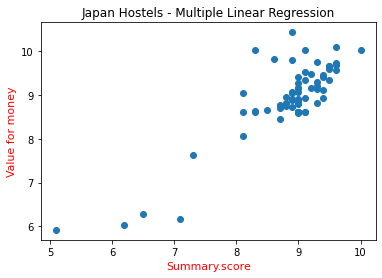


*******************************ATMOSPHERE************************


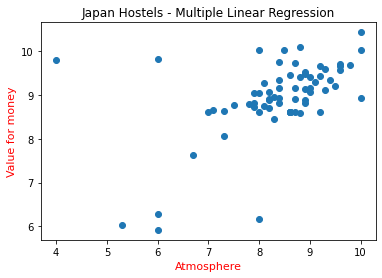


*******************************CLEANLINESS************************


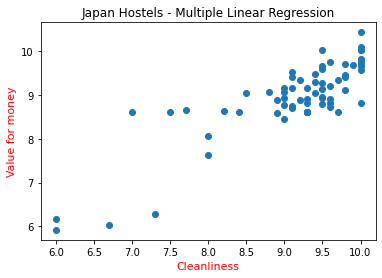


*******************************FACILITIES************************


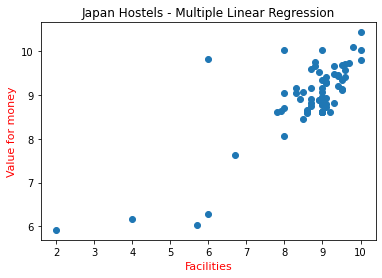


*******************************LOCATION.Y************************


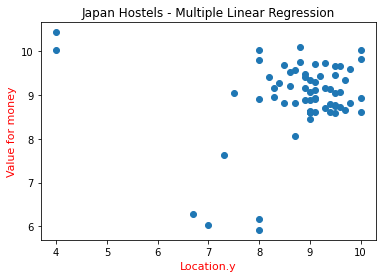


*******************************SECURITY************************


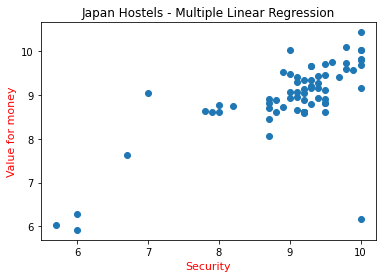


*******************************STAFF************************


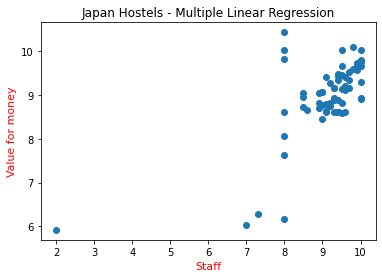

In [33]:
#Mutiple Linear Regression
MLR_regr = linear_model.LinearRegression()
#print(MLR_regr)
MLR_X_train, MLR_X_test, MLR_y_train, MLR_y_test = train_test_split(feature_variables, target_variable, train_size=0.8, test_size=0.2)
MLR_regr.fit(MLR_X_train, MLR_y_train)
MLR_y_pred = MLR_regr.predict(MLR_X_test)
#print(MLR_y_pred)
print('Coefficients:', MLR_regr.coef_)
print('Intercept:', MLR_regr.intercept_)
print('Mean squared error: %.2f' % mean_squared_error(MLR_y_test, MLR_y_pred))
print('Variance score: %.2f' % r2_score(MLR_y_test, MLR_y_pred))
for data in feature_variable_attributes:
    print("\n*******************************"+data.upper()+"************************")
    plt.xlabel(data.capitalize(), size=11, color="red")
    plt.ylabel("Value for money", size=11, color="red")
    plt.scatter(MLR_X_test[data], MLR_y_pred)
    plt.title("Japan Hostels - Multiple Linear Regression")
    plt.show()

Coefficients: [0.19908533 0.1097769  0.09076402 0.10247713 0.0415014  0.11806425
 0.06215222]
Intercept: 2.5253147879463427
Mean squared error: 0.25
Variance score: 0.76

***************************SUMMARY.SCORE****************************


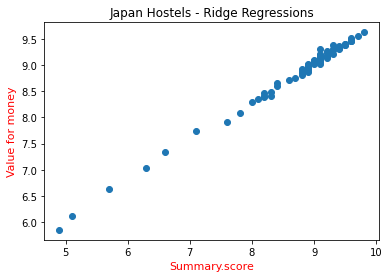


***************************ATMOSPHERE****************************


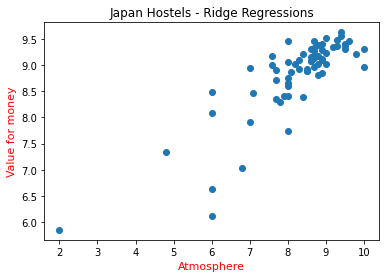


***************************CLEANLINESS****************************


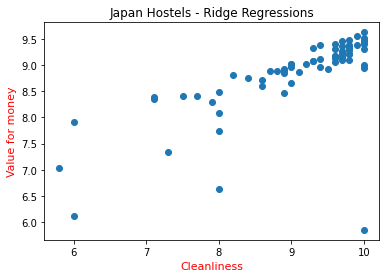


***************************FACILITIES****************************


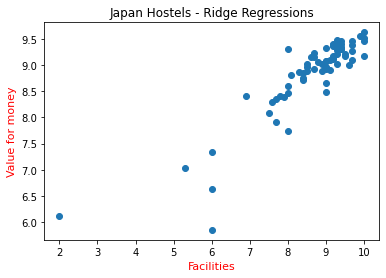


***************************LOCATION.Y****************************


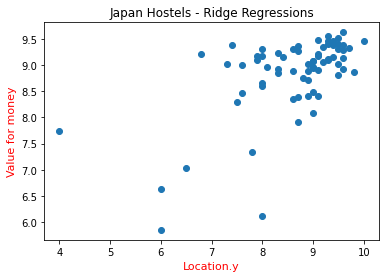


***************************SECURITY****************************


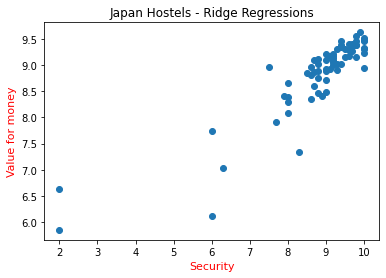


***************************STAFF****************************


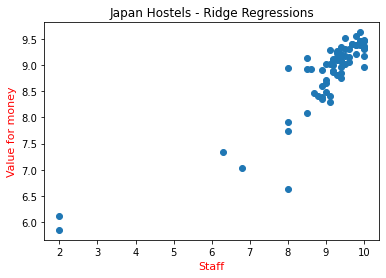

In [34]:
#Ridge Regression
RDG_regr = Ridge(fit_intercept = True, alpha = 1.0, random_state = 0, normalize = True)
RDG_X_train, RDG_X_test, RDG_y_train, RDG_y_test = train_test_split( feature_variables, target_variable, train_size = 0.8, test_size = 0.2)
RDG_regr.fit(RDG_X_train, RDG_y_train)
RDG_y_pred = RDG_regr.predict(RDG_X_test)
#print(RDG_y_pred)
print('Coefficients:', RDG_regr.coef_)
print('Intercept:', RDG_regr.intercept_)
print('Mean squared error: %.2f' % mean_squared_error(RDG_y_test, RDG_y_pred))
print('Variance score: %.2f' % r2_score(RDG_y_test, RDG_y_pred))
for data in feature_variable_attributes:
    print("\n***************************"+data.upper()+"****************************")
    plt.xlabel(data.capitalize(), size=11, color="red")
    plt.ylabel("Value for money", size=11, color="red")
    plt.scatter(RDG_X_test[data], RDG_y_pred)
    plt.title("Japan Hostels - Ridge Regressions")
    plt.show()

In [35]:
#Lasso Regression - Not working on Mac with TypeError: __init__() got an unexpected keyword argument 'positive' error
#Lasso_regr = linear_model.Lars(fit_intercept = True, fit_path = True, n_nonzero_coefs = 1, normalize = True, positive = False, precompute = 'auto', verbose = False)
#Lasso_X_train, Lasso_X_test, Lasso_y_train, Lasso_y_test = train_test_split( feature_variables, target_variable, train_size = 0.8, test_size = 0.2)
#Lasso_regr.fit(Lasso_X_train, Lasso_y_train)
#Lasso_y_pred = Lasso_regr.predict(Lasso_X_test)
#print(Lasso_y_pred)
#print('Coefficients:', Lasso_regr.coef_)
#print('Intercept:', Lasso_regr.intercept_)
#print('Mean squared error: %.2f' % mean_squared_error(Lasso_y_test, Lasso_y_pred))
#print('Variance score: %.2f' % r2_score(Lasso_y_test, Lasso_y_pred))
#for data in feature_variable_attributes:
 #   print("\n***************************"+data.upper()+"****************************")
  #  plt.xlabel(data.capitalize(), size=11, color="red")
   # plt.ylabel("Value for money", size=11, color="red")
    #plt.scatter(Lasso_X_test[data], Lasso_y_pred)
    #plt.title("Japan Hostels - Lasso Regression")
    #plt.show()

Coefficients: [0.         0.14217403 0.05544693 0.10636931 0.         0.
 0.        ]
Intercept: 6.256187204748086
Mean squared error: 0.63
Variance score: 0.40

***************************SUMMARY.SCORE****************************


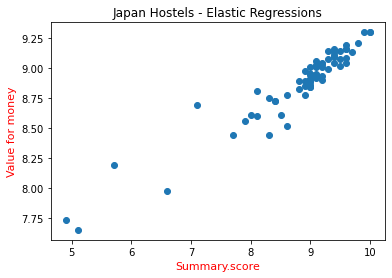


***************************ATMOSPHERE****************************


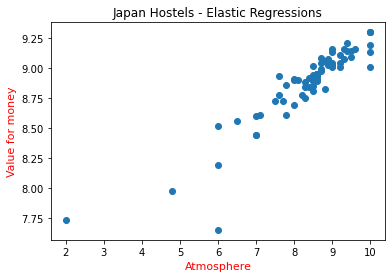


***************************CLEANLINESS****************************


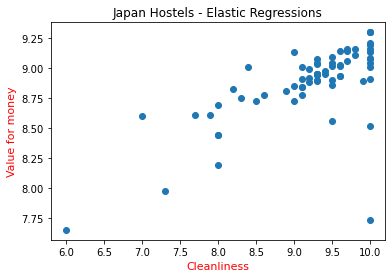


***************************FACILITIES****************************


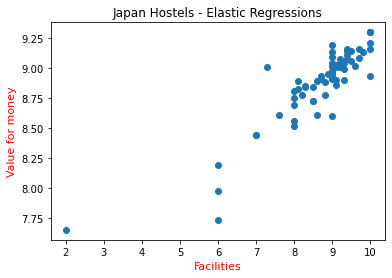


***************************LOCATION.Y****************************


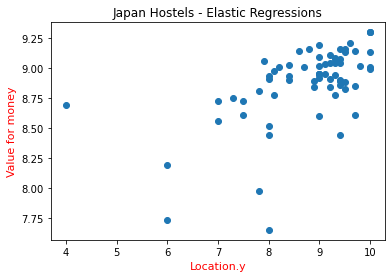


***************************SECURITY****************************


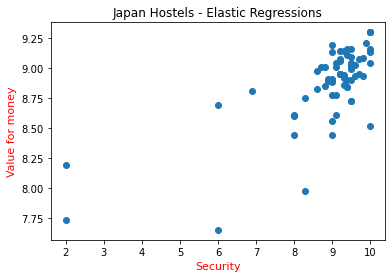


***************************STAFF****************************


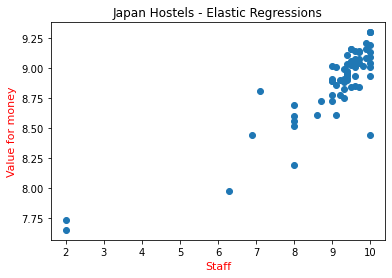

In [36]:
#Elastic Regression
ELST_regr = ElasticNet(alpha = 1.0, fit_intercept = True, l1_ratio = 0.5, max_iter = 1000, normalize = False, positive = False, precompute = False, random_state = 0, selection = 'cyclic', tol = 0.0001, warm_start = False)
ELST_X_train, ELST_X_test, ELST_y_train, ELST_y_test = train_test_split( feature_variables, target_variable, train_size = 0.8, test_size = 0.2)
ELST_regr.fit(ELST_X_train, ELST_y_train)
ELST_y_pred = ELST_regr.predict(ELST_X_test)
#print(ELST_y_pred)
print('Coefficients:', ELST_regr.coef_)
print('Intercept:', ELST_regr.intercept_)
print('Mean squared error: %.2f' % mean_squared_error(ELST_y_test, ELST_y_pred))
print('Variance score: %.2f' % r2_score(ELST_y_test, ELST_y_pred))
for data in feature_variable_attributes:
    print("\n***************************"+data.upper()+"****************************")
    plt.xlabel(data.capitalize(), size=11, color="red")
    plt.ylabel("Value for money", size=11, color="red")
    plt.scatter(ELST_X_test[data], ELST_y_pred)
    plt.title("Japan Hostels - Elastic Regressions")
    plt.show()